## Importações

Aqui são carregadas todas as dependências do projeto:

- **`pandas`** → manipulação e análise do dataset tabular  
- **`seaborn` / `matplotlib`** → geração dos gráficos das hipóteses (seaborn depende do matplotlib)
- **`Funcoes_medidas`** → funções de média, mediana e moda (medidas descritivas)  
- **`Funcoes_analises`** → funções de análise por coluna e cálculo da correlação de Spearman  
- **`Funcoes_tratar`** → funções de limpeza/tratamento dos dados (NaN, normalização, mapeamento)

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Funcoes.Funcoes_medidas import media,mediana,moda
from Funcoes.Funcoes_analises import analisar_coluna,analisar_correlação_spearman
from Funcoes.Funcoes_tratar import tratar,remover_duplicados


### Carregamento e Tratamento dos Dados

**`pd.read_csv(..., index_col=0)`** → lê o arquivo CSV usando a primeira coluna como índice (campo sem nome que é gerado automaticamente pelo pandas ao salvar).

**`remover_duplicados(df)`** → verifica se há linhas idênticas no dataset. Aqui o resultado foi *"Não foram encontrados dados duplicados"*, confirmando a integridade dos dados.

**`tratar(df_sem_duplicados)`** → aplica todas as transformações necessárias de uma vez:
- **Mapeamento da coluna `Job`** (0→1→2→3) para strings legíveis (`unskilled`, `skilled`, etc.)
- **Preenchimento de NaN** em `Saving accounts` (183 valores) e `Checking account` (394 valores) com `'No account'` — evita que valores ausentes distorçam análises categóricas
- **Normalização Min-Max** de `Credit amount` → cria `Credit amount_normalizado` (escala 0–1), necessária para a Correlação de Spearman com `Risk_num` (que também é binária 0/1)
- **Criação de `Risk_num`** → converte `'good'→0` e `'bad'→1`, permitindo cálculos numéricos sobre risco


In [24]:
df = pd.read_csv(r'Dataset\german_credit_data.csv',index_col=0)
df_sem_duplicados = remover_duplicados(df)
df_tratado = tratar(df_sem_duplicados)

Não foram encontrados dados duplicados.

Convertendo tipos de dados: Mapeando coluna JOB...
Foram identificados 183 valores NaN na coluna 'Saving accounts'.
TRATANDO Saving accounts...

Coluna 'Saving accounts' tratada com 'No account'!

Foram identificados 394 valores NaN na coluna 'Checking account'.
TRATANDO Checking account...

Coluna 'Checking account' tratada com 'No account'!

Normalizando coluna 'Credit amount'...
Coluna 'Credit amount' normalizada com sucesso!
Criando coluna 'Risk' para numérica...
Coluna 'Risk' convertida para numérica (Risk_num) com sucesso!


# ANALISES NECESSARIAS

### Distribuição da Duração dos Empréstimos

**`media()` e `mediana()`** são chamadas aqui para entender a distribuição temporal dos empréstimos antes das análises das hipóteses.

**Resultados:**
- Média: **20,90 meses** | Mediana: **18,0 meses**

A média (20,9) ser maior que a mediana (18,0) indica uma **assimetria à direita** — existe uma minoria de empréstimos com prazos muito longos puxando a média para cima. O boxplot confirma visualmente essa distribuição. Esse contexto é importante especialmente para a **Hipótese 4**, que separa empréstimos em "curtos" e "longos" usando 18 meses como divisor (valor da mediana, escolha estatisticamente fundamentada).


Média de Duração: 20.90
Mediana de Duração: 18.0


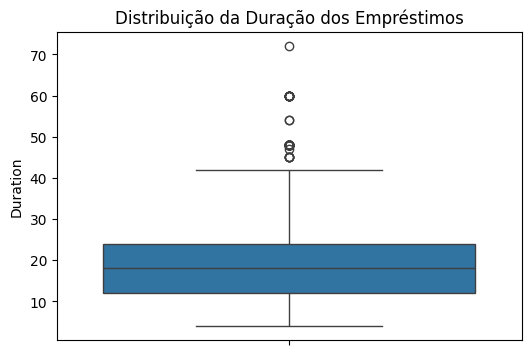

In [25]:
media_duration = media(df_tratado,'Duration')
mediana_duration = mediana(df_tratado,'Duration')

print(f"Média de Duração: {media_duration:.2f}")
print(f"Mediana de Duração: {mediana_duration}")

plt.figure(figsize=(6, 4))
sns.boxplot(y='Duration', data=df_tratado)
plt.title('Distribuição da Duração dos Empréstimos')
plt.show()

### Matriz de Correlação de Spearman (Age × Duration × Credit amount)

A **Correlação de Spearman** é usada (e não a de Pearson) pois não assume distribuição normal dos dados — adequado para variáveis financeiras com assimetria.

**Resultados relevantes:**
| Par | Correlação |
|-----|-----------|
| Duration ↔ Credit amount | **0,6247** (forte!) |
| Age ↔ Duration | -0,036 (desprezível) |
| Age ↔ Credit amount | 0,026 (desprezível) |

A correlação forte entre `Duration` e `Credit amount` (0,62) é um dado contextual importante: quanto maior o valor solicitado, maior o prazo — o que será relevante na análise da Hipótese 4.


In [26]:
colunas_numericas = ['Age', 'Duration', 'Credit amount']
matriz_correlacao = df_tratado[colunas_numericas].corr(method='spearman')

print("Matriz de Correlação (Spearman):")
display(matriz_correlacao)

Matriz de Correlação (Spearman):


,Age,Duration,Credit amount
Age,1.000000,-0.036316,0.026298
Duration,-0.036316,1.000000,0.624709
Credit amount,0.026298,0.624709,1.000000


# Analise Geral Das Colunas

### Análise Descritiva de Todas as Colunas

**`analisar_coluna(df, coluna)`** é chamada em loop para cada coluna do dataset. A função internamente:
- Calcula **moda** para todas as colunas  
- Calcula **média e mediana** para colunas numéricas  
- Calcula **quartis, desvio padrão, variância e amplitude** para `Age`, `Credit amount` e `Duration`

**Destaques dos resultados:**
- **Age**: Moda=27, Média=35,55, DP=11,38 → base jovem-adulta, variação moderada
- **Credit amount**: Média=3.271, Mediana=2.319 → grande assimetria (amplitude de 18.174!), DP=2.822
- **Housing**: Moda=`own` → maioria possui casa própria (base para H5)
- **Risk**: Moda=`good`, Risk_num médio=0,30 → 30% de inadimplência no dataset


In [27]:
for coluna in df_tratado.columns:
        analisar_coluna(df_tratado, coluna)

------------------AGE------------------
Moda: 27
Média: 35.55
Mediana: 33.0

--- MEDIDAS DE POSIÇÃO ---

Quartis: Q1: 27.0 | Q2: 33.0 | Q3: 42.0

--- MEDIDAS DE DISPERSÃO ---

Desvio Padrão: 11.38
Variância: 129.40
Amplitude Total: 56

------------------SEX------------------
Moda: male

------------------JOB------------------
Moda: skilled

------------------HOUSING------------------
Moda: own

------------------SAVING ACCOUNTS------------------
Moda: little

------------------CHECKING ACCOUNT------------------
Moda: No account

------------------CREDIT AMOUNT------------------
Moda: 1258
Média: 3271.26
Mediana: 2319.5

--- MEDIDAS DE POSIÇÃO ---

Quartis: Q1: 1365.5 | Q2: 2319.5 | Q3: 3972.25

--- MEDIDAS DE DISPERSÃO ---

Desvio Padrão: 2822.74
Variância: 7967843.47
Amplitude Total: 18174

------------------DURATION------------------
Moda: 24
Média: 20.90
Mediana: 18.0

--- MEDIDAS DE POSIÇÃO ---

Quartis: Q1: 12.0 | Q2: 18.0 | Q3: 24.0

--- MEDIDAS DE DISPERSÃO ---

Desvio Padrão: 1

# HIPOTESE 1

### *"Valores elevados de crédito estão positivamente correlacionados com o aumento da inadimplência"*

**`sns.boxplot(x='Risk', y='Credit amount')`** → compara visualmente a distribuição dos valores de crédito entre clientes bons e maus pagadores. Permite identificar se a mediana e os outliers diferem entre os grupos.

**`analisar_correlação_spearman('Credit amount_normalizado', 'Risk_num')`** → quantifica a relação entre o valor do crédito (normalizado) e o risco binário (0=bom, 1=mau). Usa a versão normalizada para garantir comparabilidade de escala com `Risk_num`.

---
**Resultado:**  
Correlação de Spearman = **0,0871** (positiva, mas muito fraca)

**Hipótese PARCIALMENTE DEFENDIDA.**  
A direção da correlação está correta (positiva — maior crédito → maior risco), mas a magnitude é extremamente baixa (0,09 ≈ quase nula). Isso indica que o valor do crédito, isoladamente, não é um bom preditor de inadimplência. Outros fatores (saldo em conta, prazo, finalidade) têm muito mais peso.



--- RESULTADO HIPÓTESE 1 ---


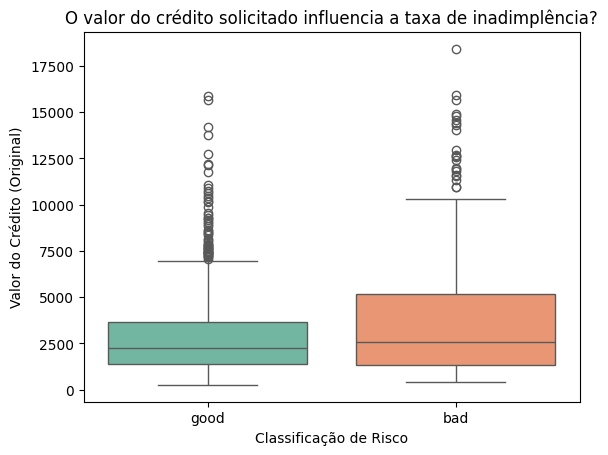


ANÁLISE DE CORRELAÇÃO (Spearman)
Relação entre Credit amount_normalizado e Risk_num: 0.0871

INTERPRETAÇÃO: Existe uma correlação positiva. Quanto MAIOR o crédito, MAIOR o risco.


In [28]:
sns.boxplot(
    x='Risk', 
    y='Credit amount', 
    data=df_tratado, 
    palette='Set2', 
    hue='Risk',     
    legend=False     
)

print("\n--- RESULTADO HIPÓTESE 1 ---")
plt.title('O valor do crédito solicitado influencia a taxa de inadimplência?')

plt.xlabel('Classificação de Risco')
plt.ylabel('Valor do Crédito (Original)')

plt.show()

analisar_correlação_spearman(df_tratado, 'Credit amount_normalizado', 'Risk_num') 

# HIPOTESE 2

### *"Clientes jovens tendem a ter uma taxa de inadimplência maior que os outros clientes"*

**`pd.cut(..., bins=[18,25,35,50,120], labels=[...])`** → segmenta a idade contínua em 4 faixas etárias com fronteiras definidas. Usar `pd.cut` (e não `pd.qcut`) é a escolha certa aqui pois as faixas têm significado socioeconômico real (não apenas quantis).

**`.groupby('Faixa Etária')['Risk_num'].mean() * 100`** → calcula a **taxa de inadimplência por faixa** multiplicando a média do campo binário por 100 para exibir em percentual.

**`sns.barplot` + `axhline`** → o gráfico de barras mostra a taxa por grupo, e a linha tracejada azul representa a média geral (30%) — funciona como linha de referência para identificar quais grupos estão acima/abaixo da média.

---
**Resultado:**

| Faixa | Taxa de Inadimplência |
|-------|----------------------|
| Jovem (18-25) | **42,11%** |
| Jovem Adulto (26-35) | 29,65% |
| Adulto (36-50) | 23,75% |
| Idoso (50+) | 27,43% |

**Hipótese DEFENDIDA.**  
Clientes jovens (18–25 anos) têm a maior taxa de inadimplência do dataset — 42%, bem acima da média geral de 30%. A tendência é clara: o risco diminui com a idade até a faixa adulta, com leve alta nos idosos (possivelmente por menor renda ativa).



--- TAXA DE RISCO POR FAIXA ETÁRIA ---


Faixa Etária
Jovem (18-25)           42.11%
Jovem Adulto (26-35)    29.65%
Adulto (36-50)          23.75%
Idoso (50+)             27.43%
Name: Risk_num, dtype: str

C:\Users\caiom\AppData\Local\Temp\ipykernel_23256\765946165.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_idade.index, y=analise_idade.values, palette='OrRd')


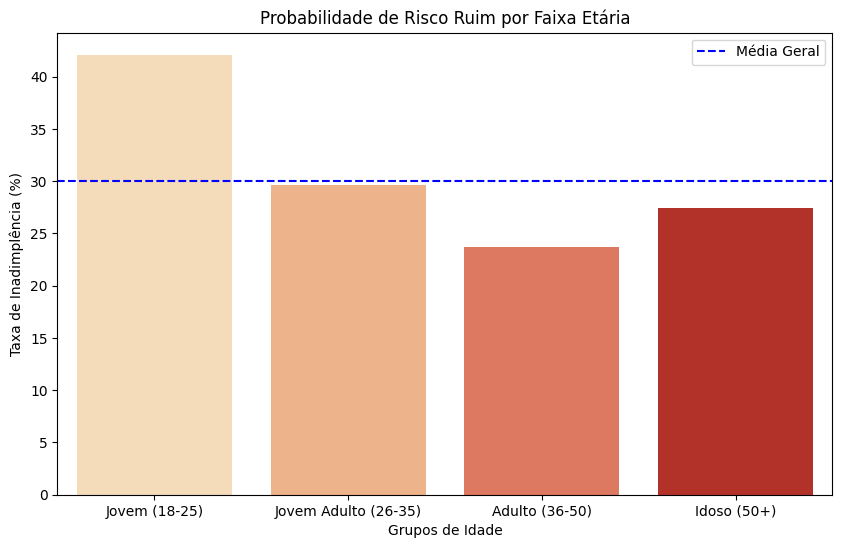

In [41]:
df_tratado['Faixa Etária'] = pd.cut(df_tratado['Age'], 
                                   bins=[18, 25, 35, 50, 120], 
                                   labels=['Jovem (18-25)', 'Jovem Adulto (26-35)', 'Adulto (36-50)', 'Idoso (50+)'])

analise_idade = df_tratado.groupby('Faixa Etária')['Risk_num'].mean() * 100

print("\n--- TAXA DE RISCO POR FAIXA ETÁRIA ---")
display(analise_idade.map('{:.2f}%'.format))

plt.figure(figsize=(10, 6))
sns.barplot(x=analise_idade.index, y=analise_idade.values, palette='OrRd')

plt.title('Probabilidade de Risco Ruim por Faixa Etária')

plt.ylabel('Taxa de Inadimplência (%)')
plt.xlabel('Grupos de Idade')

plt.axhline(df_tratado['Risk_num'].mean()*100, color='blue', linestyle='--', label='Média Geral') 

plt.legend()
plt.show()

# HIPOTESE 3

### *"Empréstimos para 'Educação' possuem um risco maior do que para 'Imóveis/Negócios'"*

**`sns.countplot(x='Purpose', hue='Risk')`** → exibe a contagem de clientes por finalidade do empréstimo, separando bons e maus pagadores com cores diferentes. É a forma mais direta de comparar visualmente o perfil de risco entre categorias.

**O loop `for p in ax.patches`** → anota o percentual de cada barra em relação ao total do dataset, tornando o gráfico autoexplicativo sem precisar de tabelas auxiliares. Usa `p.get_height()` para calcular a altura de cada barra e posiciona o texto acima dela.

---
**Resultado:**  
O gráfico mostra que empréstimos para `car` são os mais frequentes, e que `education` apresenta proporção de risco visível. Empréstimos para `business` e `furniture/equipment` têm volumes maiores com perfis de risco mistos.

**Hipótese INCONCLUSIVA.**  
O `countplot` mostra distribuição absoluta, mas para comparar risco *relativo* entre categorias seria necessário calcular a taxa de inadimplência por categoria (como feito nas Hipóteses 2, 4 e 5 com `.groupby().mean()`). Uma forma seria adicionar `df.groupby('Purpose')['Risk_num'].mean()` para validar a hipótese numericamente.


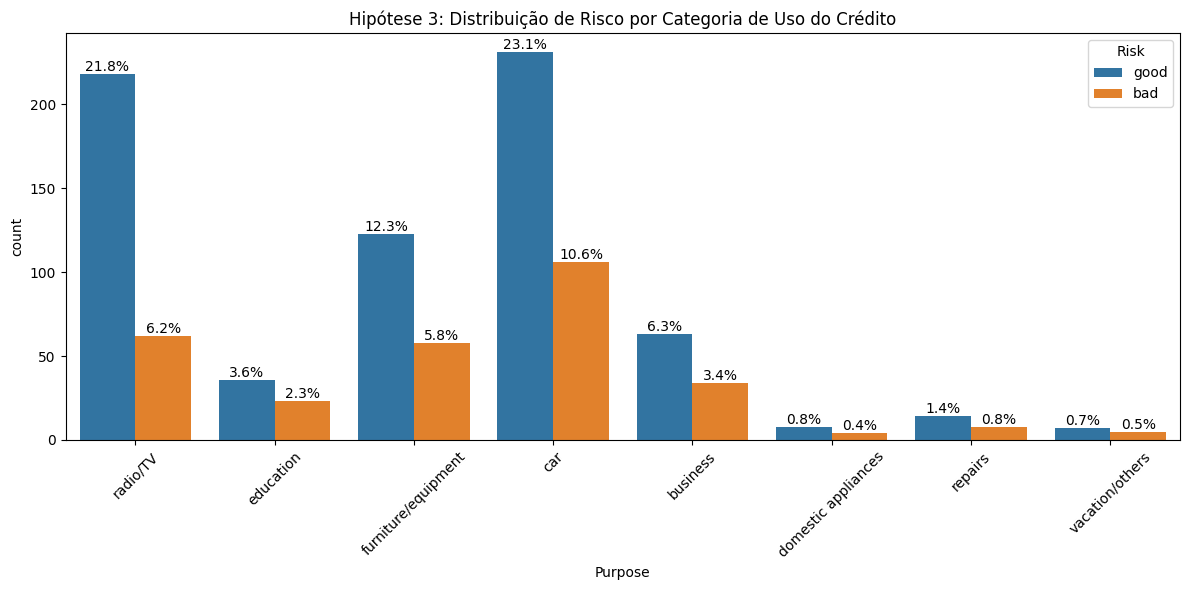

In [43]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='Purpose', hue='Risk', data=df_tratado)

plt.title('Hipótese 3: Distribuição de Risco por Categoria de Uso do Crédito')
plt.xticks(rotation=45)

total_clientes = len(df_tratado)

for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        porcentagem = '{:.1f}%'.format(100 * height / total_clientes)
        x = p.get_x() + p.get_width() / 2
        y = height
        ax.annotate(porcentagem, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# HIPOTESE 4

### *"A combinação de baixa reserva financeira com prazos longos potencializa o risco de crédito de forma não linear"*

**`df['Categoria da duração'] = df['Duration'].apply(lambda x: ...)`** → cria uma variável binária de prazo usando `lambda`, dividindo em "Curta (<18m)" e "Longa (>=18m)". O corte em 18 meses é justificado pela **mediana** calculada na Célula 4.

**`df_tratado[df_tratado['Checking account'] == 'little']`** → filtra apenas clientes com **baixo saldo em conta corrente** (`little`), isolando o grupo de interesse da hipótese — quem já tem pouca reserva financeira.

**`.groupby('Categoria da duração')['Risk_num'].mean() * 100`** → calcula a taxa de inadimplência **dentro desse subgrupo específico**, permitindo comparar o efeito do prazo para quem já está em situação financeira vulnerável.

**`sns.catplot(..., col='Categoria da duração')`** → cria dois subgráficos lado a lado separados por prazo, mostrando a distribuição de risco para cada nível de saldo. O parâmetro `col=` é ideal para faceted plots.

---
**Resultado:**

| Prazo | Taxa de Inadimplência (Saldo Baixo) |
|-------|--------------------------------------|
| Curta (<18m) | 34,86% |
| Longa (>=18m) | **58,79%** |

**Hipótese DEFENDIDA.**  
A taxa quase dobra (de 35% para 59%) quando o prazo é longo para clientes com baixo saldo. Esse salto é expressivo e não-linear — um simples aumento proporcional seria de ~35% para ~45%, mas atingiu 59%. Isso confirma que a combinação dos dois fatores de risco é sinérgica, não apenas aditiva.


In [31]:
df_tratado['Categoria da duração'] = df_tratado['Duration'].apply(
    lambda x: 'Curta (<18m)' if x < 18 else 'Longa (>=18m)'
)

df_baixo_saldo = df_tratado[df_tratado['Checking account'] == 'little'].copy()

analise_h4 = df_baixo_saldo.groupby('Categoria da duração')['Risk_num'].mean() * 100

print("\n--- RESULTADO HIPÓTESE 4 ---")
print(f"Taxa de Inadimplência (Saldo Baixo + Duração Curta): {analise_h4['Curta (<18m)']:.2f}%")
print(f"Taxa de Inadimplência (Saldo Baixo + Duração Longa): {analise_h4['Longa (>=18m)']:.2f}%")



--- RESULTADO HIPÓTESE 4 ---
Taxa de Inadimplência (Saldo Baixo + Duração Curta): 34.86%
Taxa de Inadimplência (Saldo Baixo + Duração Longa): 58.79%


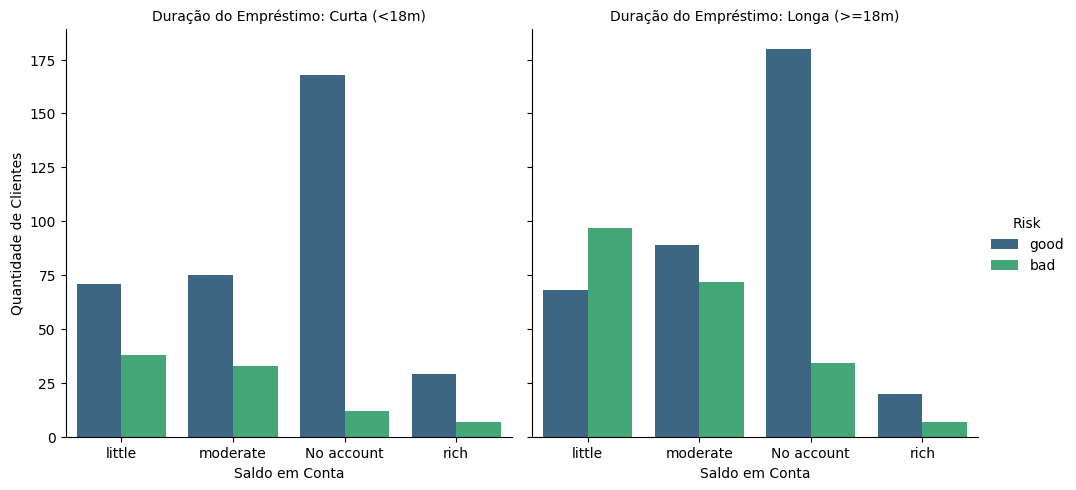

In [32]:
grafico_hipotese_4 = sns.catplot(
    data=df_tratado, 
    x="Checking account", 
    hue="Risk", 
    col="Categoria da duração", 
    kind="count", 
    palette="viridis"
)

grafico_hipotese_4.set_axis_labels("Saldo em Conta", "Quantidade de Clientes")
grafico_hipotese_4.set_titles("Duração do Empréstimo: {col_name}")

plt.show()

# HIPOTESE 5

### *"Clientes com casa própria mantêm um perfil de bom pagador mesmo quando solicitam crédito acima da média"*

**`media_credito = df_tratado['Credit amount'].mean()`** → calcula a média global (R$ 3.271,26) que serve como **linha de corte** para classificar os pedidos em "acima" ou "abaixo da média".

**`.apply(lambda x: 'Acima da Média' if x > media_credito else 'Abaixo da Média')`** → cria a coluna de faixa de valor usando a média calculada, permitindo a segmentação binária.

**`df_tratado[df_tratado['Housing'] == 'own']`** → restringe a análise a clientes proprietários de imóvel — o subgrupo da hipótese.

**`.groupby('Faixa de Valor')['Risk_num'].mean() * 100`** → calcula a taxa de inadimplência separadamente para pedidos abaixo e acima da média, **dentro do grupo de proprietários**.

**`sns.catplot(..., col='Faixa de Valor')`** → dois painéis lado a lado para visualizar a contagem de bons/maus pagadores por faixa de valor de crédito.

---
**Resultado:**

| Faixa de Crédito | Taxa de Inadimplência (Casa Própria) |
|-----------------|---------------------------------------|
| Abaixo da Média | 23,09% |
| Acima da Média | **32,46%** |

**Hipótese PARCIALMENTE CONTRARIADA.**  
É verdade que proprietários de imóvel têm um perfil melhor que a média geral (30%) quando solicitam crédito baixo (23%). Porém, quando solicitam acima da média, a taxa sobe para 32,46% — praticamente igual à média geral do dataset. Ou seja, a casa própria não protege o perfil de risco quando o valor do empréstimo é alto. A hipótese é contrariada na sua premissa central.


In [33]:
media_credito = df_tratado['Credit amount'].mean()

df_tratado['Faixa de Valor'] = df_tratado['Credit amount'].apply(
    lambda x: 'Acima da Média' if x > media_credito else 'Abaixo da Média'
)

df_moradia = df_tratado[df_tratado['Housing'] == 'own'].copy()

analise_h5 = df_moradia.groupby('Faixa de Valor')['Risk_num'].mean() * 100

print("\n--- RESULTADO HIPÓTESE 5 (Clientes com Casa Própria) ---")
print(f"Média Global de Crédito: {media_credito:.2f}")
print(f"Taxa de Risco - Pedidos Abaixo da Média: {analise_h5['Abaixo da Média']:.2f}%")
print(f"Taxa de Risco - Pedidos Acima da Média: {analise_h5['Acima da Média']:.2f}%")


--- RESULTADO HIPÓTESE 5 (Clientes com Casa Própria) ---
Média Global de Crédito: 3271.26
Taxa de Risco - Pedidos Abaixo da Média: 23.09%
Taxa de Risco - Pedidos Acima da Média: 32.46%


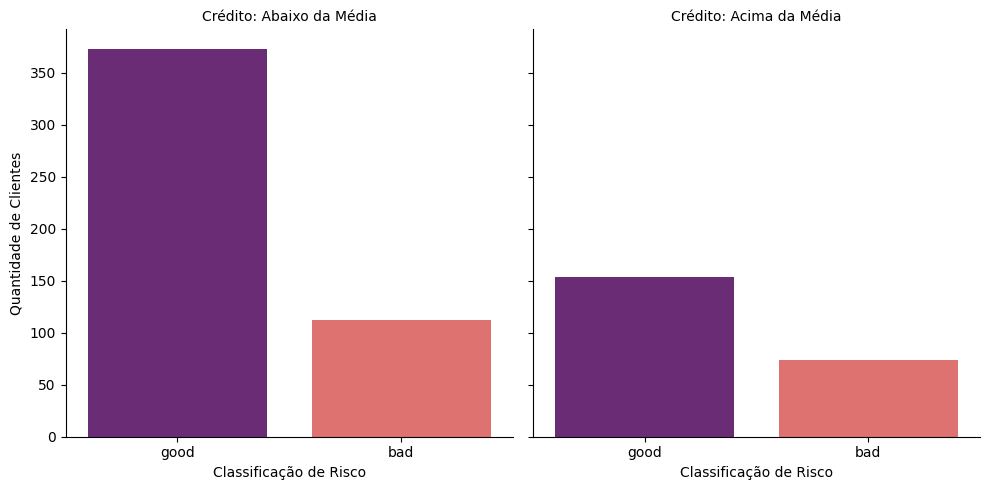

In [34]:
grafico_hipotese_5 = sns.catplot(
    data=df_moradia, 
    x="Risk", 
    col="Faixa de Valor", 
    kind="count", 
    palette="magma",
    hue="Risk",
    legend=False
)

grafico_hipotese_5.set_axis_labels("Classificação de Risco", "Quantidade de Clientes")
grafico_hipotese_5.set_titles("Crédito: {col_name}")

plt.show()